# Digital Payments Customer Analytics (v3) — Segmentation, Churn, Retention & Forecasting

SQL-driven analysis of a digital payments transaction dataset: RFM segmentation (with a KMeans
robustness check), churn analysis (with threshold sensitivity), cohort retention, and regression
forecasting (with a naive baseline, residual diagnostics, and prediction intervals).

**Dataset:** Real-world retail transactions (UCI Online Retail II), loaded directly from a Kaggle input.
The pipeline (SQL, statistical tests, forecasting approach) is dataset-agnostic.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

COLORS = {"primary": "#2563eb", "secondary": "#16a34a", "warn": "#dc2626", "muted": "#6b7280"}

## 2. Configuration

In [2]:
SEED = 42
CHURN_THRESHOLD_CANDIDATES = [30, 60, 90, 120, 180]
FORECAST_TEST_MONTHS = 3
N_BOOTSTRAP = 1000

## 3. Load & Prepare the Real Transaction Dataset

We load the **UCI Online Retail II** dataset from a Kaggle input path.
The raw data contains invoices, quantities, and unit prices.
We transform it into the exact schema used by the rest of the notebook:
`customer_id`, `transaction_date`, `amount`, `category`, `city`.

**Preprocessing steps:**
- Combine both yearly sheets (2009-2010 and 2010-2011)
- Create `amount = Quantity * UnitPrice`
- Drop rows with missing Customer ID
- Keep only positive amounts (remove returns/credits)
- Add dummy `category` and `city` columns to match the original schema
- Format the date as YYYY-MM-DD

In [3]:
# Load both sheets from the Excel file
path = "/kaggle/input/datasets/nehamalik10/online-retail-ii-dataset/online_retail_II.xlsx"
sheet1 = pd.read_excel(path, sheet_name="Year 2009-2010", dtype={"Customer ID": str})
sheet2 = pd.read_excel(path, sheet_name="Year 2010-2011", dtype={"Customer ID": str})

# Combine
df_raw = pd.concat([sheet1, sheet2], ignore_index=True)
print("Raw rows:", len(df_raw))

# Rename and create amount
df = df_raw[["Customer ID", "InvoiceDate", "Quantity", "Price"]].copy()
df.rename(columns={"Customer ID": "customer_id", "InvoiceDate": "transaction_date"}, inplace=True)

# Drop missing customer IDs and convert to integer
df = df.dropna(subset=["customer_id"])
df["customer_id"] = df["customer_id"].astype(int)

# Calculate transaction amount (positive only)
df["amount"] = df["Quantity"] * df["Price"]
df = df[df["amount"] > 0]

# Add dummy category and city (real data lacks them; they are not used in core analysis)
df["category"] = "General Retail"
df["city"] = "United Kingdom"

# Keep only the required columns in the right order
transactions = df[["customer_id", "transaction_date", "amount", "category", "city"]].copy()

# Format date as string (YYYY-MM-DD) for SQLite compatibility
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"]).dt.strftime("%Y-%m-%d")

# Sort by date
transactions = transactions.sort_values("transaction_date").reset_index(drop=True)

print(f"{len(transactions):,} transactions across {transactions['customer_id'].nunique():,} customers")
print(f"Date range: {transactions['transaction_date'].min()} to {transactions['transaction_date'].max()}")
transactions.head()

Raw rows: 1067371
805,549 transactions across 5,878 customers
Date range: 2009-12-01 to 2011-12-09


,customer_id,transaction_date,amount,category,city
0,13085,2009-12-01,83.40,General Retail,United Kingdom
1,13097,2009-12-01,8.85,General Retail,United Kingdom
2,13097,2009-12-01,8.85,General Retail,United Kingdom
3,13097,2009-12-01,1.95,General Retail,United Kingdom
4,13097,2009-12-01,3.75,General Retail,United Kingdom


## 4. Load into SQLite

In [4]:
conn = sqlite3.connect(":memory:")
transactions.to_sql("transactions", conn, index=False, if_exists="replace")
conn.execute("CREATE INDEX idx_customer ON transactions(customer_id);")
conn.execute("CREATE INDEX idx_date ON transactions(transaction_date);")
print("Loaded into SQLite.")

Loaded into SQLite.


## 5. Monthly revenue & transaction volume trend (SQL)

In [5]:
monthly_query = '''
SELECT strftime('%Y-%m', transaction_date) AS month,
       COUNT(*) AS n_transactions,
       ROUND(SUM(amount), 2) AS revenue,
       COUNT(DISTINCT customer_id) AS active_customers,
       ROUND(AVG(amount), 2) AS avg_transaction_value
FROM transactions
GROUP BY month
ORDER BY month;
'''
monthly = pd.read_sql(monthly_query, conn)
monthly_full = monthly.iloc[:-1].reset_index(drop=True)   # exclude partial final month
print(f"Excluded partial final month ({monthly['month'].iloc[-1]}).")
monthly_full

Excluded partial final month (2011-12).


,month,n_transactions,revenue,active_customers,avg_transaction_value
0,2009-12,30754,"686,654.16",955,22.33
1,2010-01,21775,"557,319.06",720,25.59
2,2010-02,23367,"506,371.07",772,21.67
3,2010-03,32301,"699,608.99",1057,21.66
4,2010-04,27235,"594,609.19",942,21.83
5,2010-05,28644,"599,985.79",966,20.95
6,2010-06,31188,"639,066.58",1041,20.49
7,2010-07,27032,"591,636.74",928,21.89
8,2010-08,26392,"604,242.65",911,22.89
9,2010-09,34599,"831,615.00",1145,24.04


## 6. Visualization 1 — Monthly revenue & active customers

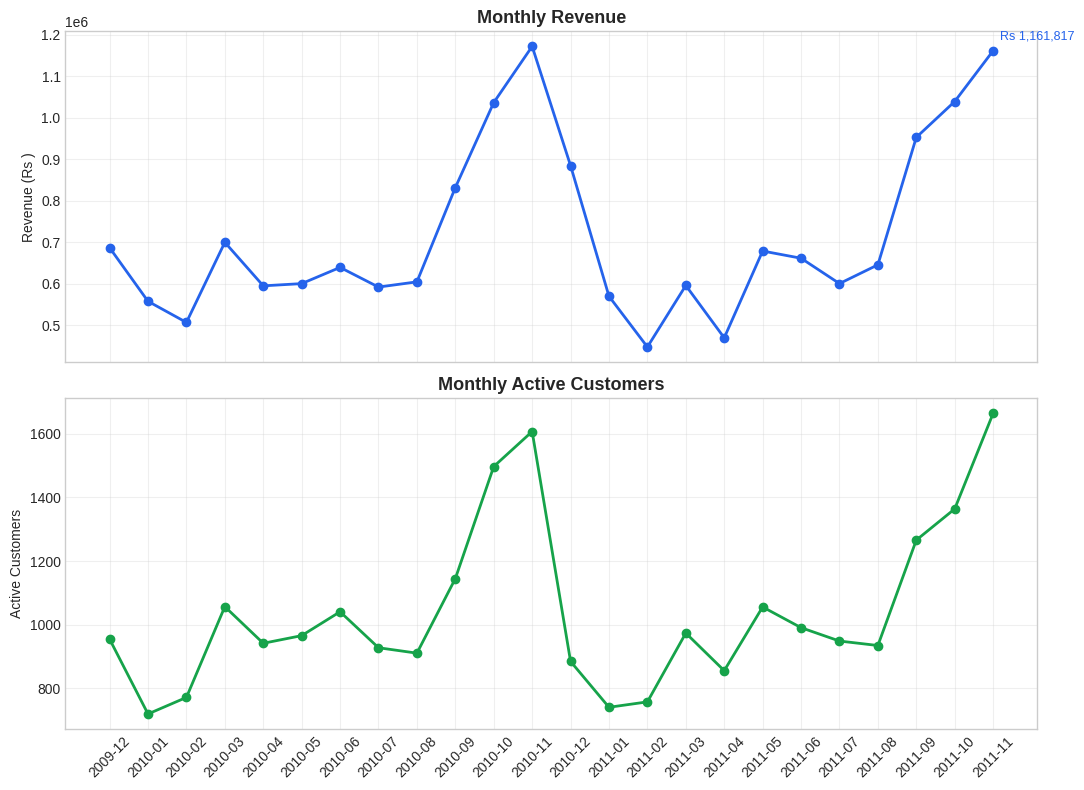

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(monthly_full["month"], monthly_full["revenue"], marker="o", color=COLORS["primary"], linewidth=2)
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Revenue (Rs )")
axes[0].annotate(f"Rs {monthly_full['revenue'].iloc[-1]:,.0f}", 
                  xy=(len(monthly_full)-1, monthly_full["revenue"].iloc[-1]),
                  xytext=(5, 8), textcoords="offset points", fontsize=9, color=COLORS["primary"])

axes[1].plot(monthly_full["month"], monthly_full["active_customers"], marker="o", color=COLORS["secondary"], linewidth=2)
axes[1].set_title("Monthly Active Customers")
axes[1].set_ylabel("Active Customers")
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Is the growth trend statistically real?

In [7]:
x = np.arange(len(monthly_full))
y = monthly_full["revenue"].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Estimated growth: Rs {slope:,.0f} per month")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value: {p_value:.2e}  (< 0.05 means the trend is statistically distinguishable from zero)")
print(f"95% CI on slope: [Rs {slope - 1.96*std_err:,.0f}, Rs {slope + 1.96*std_err:,.0f}] per month")

Estimated growth: Rs 10,934 per month
R-squared: 0.133
p-value: 8.02e-02  (< 0.05 means the trend is statistically distinguishable from zero)
95% CI on slope: [Rs -749, Rs 22,618] per month


## 8. RFM metrics (SQL) — and checking the distributions before scoring them

In [8]:
rfm_query = '''
WITH last_date AS (SELECT MAX(transaction_date) AS max_date FROM transactions),
customer_stats AS (
    SELECT customer_id, MAX(transaction_date) AS last_txn_date, COUNT(*) AS frequency,
           ROUND(SUM(amount), 2) AS monetary,
           CAST((julianday((SELECT max_date FROM last_date)) - julianday(MAX(transaction_date))) AS INT) AS recency_days
    FROM transactions GROUP BY customer_id
)
SELECT customer_id, recency_days, frequency, monetary,
       NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
       NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
       NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
FROM customer_stats;
'''
rfm = pd.read_sql(rfm_query, conn)

skew_recency = stats.skew(rfm["recency_days"])
skew_freq = stats.skew(rfm["frequency"])
skew_mon = stats.skew(rfm["monetary"])
print(f"Skewness — Recency: {skew_recency:.2f}, Frequency: {skew_freq:.2f}, Monetary: {skew_mon:.2f}")
print("(> 1 is generally considered highly right-skewed)")

Skewness — Recency: 0.89, Frequency: 18.05, Monetary: 25.31
(> 1 is generally considered highly right-skewed)


## 9. Visualization 2 — RFM distributions

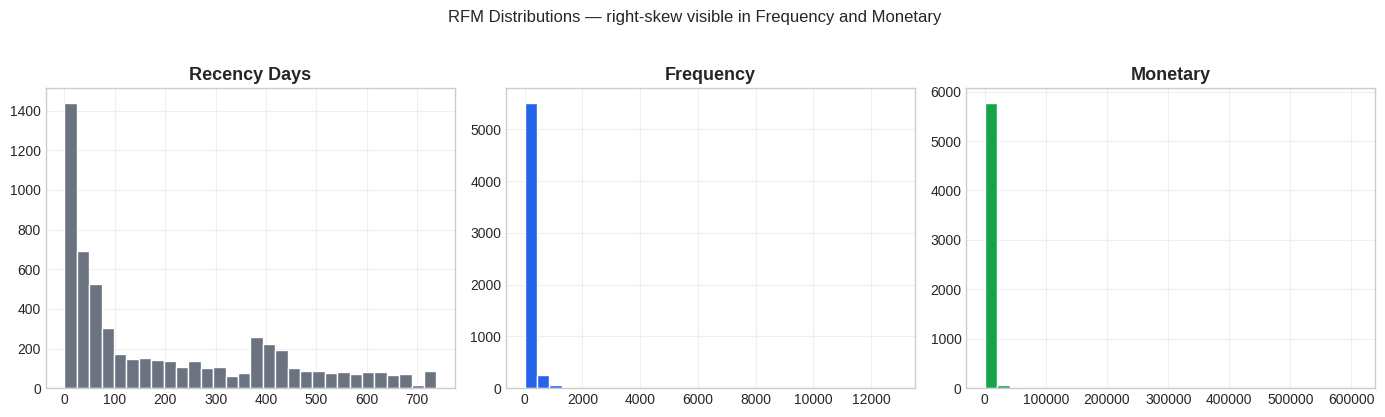

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ["recency_days", "frequency", "monetary"], [COLORS["muted"], COLORS["primary"], COLORS["secondary"]]):
    ax.hist(rfm[col], bins=30, color=color, edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.grid(alpha=0.3)
plt.suptitle("RFM Distributions — right-skew visible in Frequency and Monetary", y=1.03)
plt.tight_layout()
plt.show()

## 10. Segmentation — RFM business rules, cross-checked against KMeans clustering

In [10]:
def label_segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2:
        return "Loyal"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Hibernating"

rfm["segment"] = rfm.apply(label_segment, axis=1)

# KMeans on log-transformed, standardized RFM
rfm_features = pd.DataFrame({
    "log_recency": np.log1p(rfm["recency_days"]),
    "log_frequency": np.log1p(rfm["frequency"]),
    "log_monetary": np.log1p(rfm["monetary"]),
})
features_z = (rfm_features - rfm_features.mean()) / rfm_features.std()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(features_z)

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"), avg_recency_days=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"), avg_monetary=("monetary", "mean"),
).round(1).sort_values("customers", ascending=False)
print("RFM business-rule segments:")
print(segment_summary)

crosstab = pd.crosstab(rfm["segment"], rfm["cluster"])
print("\nRFM segment vs. KMeans cluster (rows should concentrate in few columns if they agree):")
print(crosstab)

RFM business-rule segments:
             customers  avg_recency_days  avg_frequency  avg_monetary
segment                                                              
Champions         1797             28.70         324.90      7,391.00
Lost              1771            413.10          20.10        330.40
At Risk            934            294.30         142.70      2,304.30
Loyal              760             37.10          54.80        948.40
Hibernating        616            153.30          18.20      1,629.40

RFM segment vs. KMeans cluster (rows should concentrate in few columns if they agree):
cluster        0    1     2    3    4
segment                              
At Risk        0  589     0  345    0
Champions    766   10     0  779  242
Hibernating    1  211   161   11  232
Lost           0  655  1116    0    0
Loyal          5   29     7   38  681


## 11. Visualization 3 — Segment distribution & RFM/cluster agreement

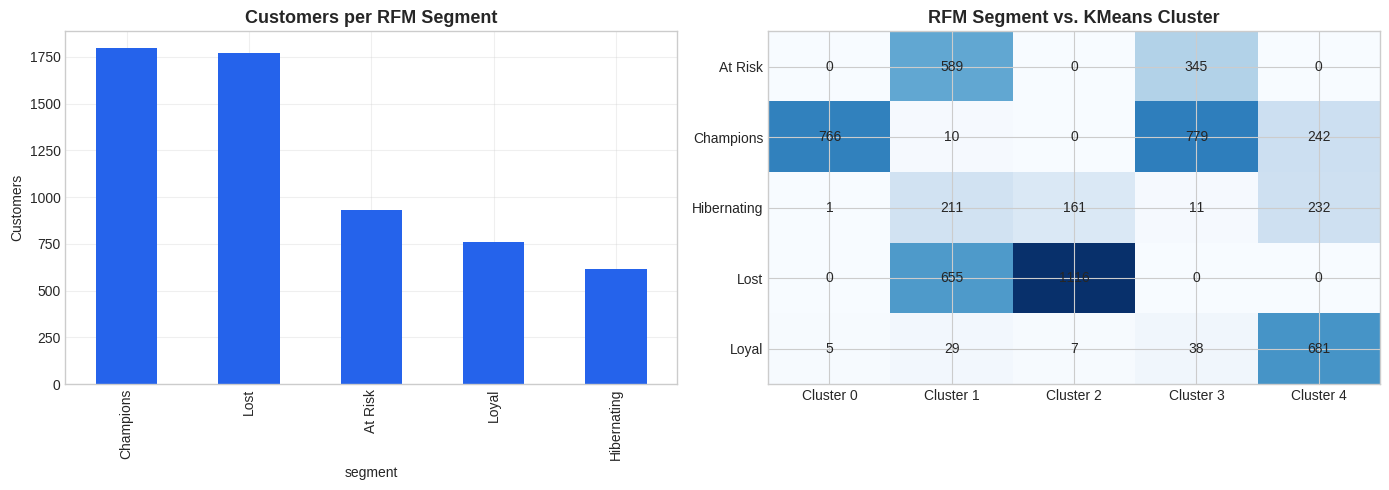

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_summary["customers"].plot(kind="bar", ax=axes[0], color=COLORS["primary"])
axes[0].set_title("Customers per RFM Segment")
axes[0].set_ylabel("Customers")
axes[0].grid(alpha=0.3)

im = axes[1].imshow(crosstab.values, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(crosstab.columns)))
axes[1].set_xticklabels([f"Cluster {c}" for c in crosstab.columns])
axes[1].set_yticks(range(len(crosstab.index)))
axes[1].set_yticklabels(crosstab.index)
axes[1].set_title("RFM Segment vs. KMeans Cluster")
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        axes[1].text(j, i, crosstab.values[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Churn threshold — sensitivity analysis instead of an arbitrary number

In [12]:
last_date = pd.to_datetime(transactions["transaction_date"]).max()
last_txn_per_customer = pd.to_datetime(transactions.groupby("customer_id")["transaction_date"].max())
days_inactive = (last_date - last_txn_per_customer).dt.days

sensitivity = pd.DataFrame({
    "threshold_days": CHURN_THRESHOLD_CANDIDATES,
    "churn_rate_pct": [round((days_inactive > t).mean() * 100, 1) for t in CHURN_THRESHOLD_CANDIDATES],
})
sensitivity

,threshold_days,churn_rate_pct
0,30,71.60
1,60,59.00
2,90,50.90
3,120,46.90
4,180,40.80


## 13. Visualization 4 — Churn rate vs. threshold

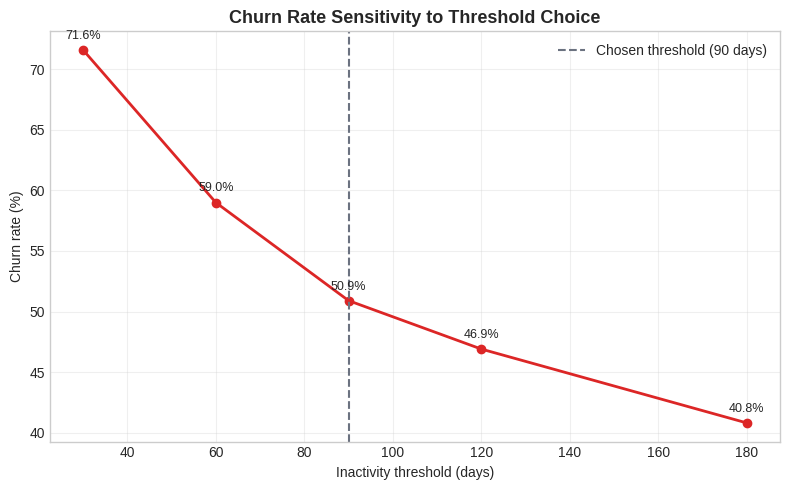

Using 90 days: churn rate is not a knife-edge number — it declines gradually
from 30 to 180 days rather than jumping sharply at any one point, so 90 days (a common fintech
benchmark for 'inactive user') is a reasonable, defensible choice rather than an arbitrary one.


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sensitivity["threshold_days"], sensitivity["churn_rate_pct"], marker="o", color=COLORS["warn"], linewidth=2)
ax.axvline(90, color=COLORS["muted"], linestyle="--", label="Chosen threshold (90 days)")
for _, row in sensitivity.iterrows():
    ax.annotate(f"{row['churn_rate_pct']}%", (row["threshold_days"], row["churn_rate_pct"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("Inactivity threshold (days)")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate Sensitivity to Threshold Choice")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CHURN_THRESHOLD_DAYS = 90
print(f"Using {CHURN_THRESHOLD_DAYS} days: churn rate is not a knife-edge number — it declines gradually")
print("from 30 to 180 days rather than jumping sharply at any one point, so 90 days (a common fintech")
print("benchmark for 'inactive user') is a reasonable, defensible choice rather than an arbitrary one.")

## 14. Cohort retention analysis (SQL)

In [14]:
cohort_query = '''
WITH first_purchase AS (
    SELECT customer_id, MIN(strftime('%Y-%m', transaction_date)) AS cohort_month
    FROM transactions GROUP BY customer_id
),
txn_months AS (
    SELECT t.customer_id, fp.cohort_month, strftime('%Y-%m', t.transaction_date) AS txn_month
    FROM transactions t JOIN first_purchase fp ON t.customer_id = fp.customer_id
)
SELECT cohort_month, txn_month, COUNT(DISTINCT customer_id) AS active_customers
FROM txn_months GROUP BY cohort_month, txn_month ORDER BY cohort_month, txn_month;
'''
cohort_raw = pd.read_sql(cohort_query, conn)
cohort_raw["cohort_dt"] = pd.to_datetime(cohort_raw["cohort_month"])
cohort_raw["txn_dt"] = pd.to_datetime(cohort_raw["txn_month"])
cohort_raw["month_number"] = ((cohort_raw["txn_dt"].dt.year - cohort_raw["cohort_dt"].dt.year) * 12 +
                                (cohort_raw["txn_dt"].dt.month - cohort_raw["cohort_dt"].dt.month))
cohort_pivot = cohort_raw.pivot_table(index="cohort_month", columns="month_number", values="active_customers")
retention_pct = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

non_monotonic = sum(1 for _, row in retention_pct.iterrows()
                     if any(a < b for a, b in zip(row.dropna(), row.dropna()[1:])))
print(f"Cohorts with non-monotonic retention (data artifact check): {non_monotonic} / {len(retention_pct)}")
retention_pct.iloc[:, :12].round(1)

Cohorts with non-monotonic retention (data artifact check): 22 / 25


month_number,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2009-12,100.00,35.30,33.40,42.50,38.00,35.90,37.70,34.20,33.60,36.20,42.20,49.50
2010-01,100.00,20.60,31.10,30.50,26.40,30.00,25.80,23.00,27.90,31.90,30.30,17.20
2010-02,100.00,23.80,22.50,29.10,24.60,20.10,19.30,28.60,25.40,27.50,11.50,12.60
2010-03,100.00,19.00,23.00,24.20,23.30,20.30,24.60,30.20,27.50,10.80,11.50,14.20
2010-04,100.00,19.40,19.40,16.30,18.40,22.40,27.60,26.20,10.50,10.90,7.50,13.90
2010-05,100.00,15.70,16.90,17.30,17.70,25.60,21.30,12.60,5.90,8.30,11.40,13.40
2010-06,100.00,17.40,18.90,20.40,23.00,28.50,12.60,8.90,8.10,11.90,10.70,13.70
2010-07,100.00,15.60,18.30,29.60,29.00,14.00,11.30,14.50,14.50,11.30,13.40,14.50
2010-08,100.00,20.40,29.60,32.10,17.30,11.70,9.90,12.30,13.60,13.00,13.00,12.30


## 15. Visualization 5 — Cohort retention heatmap

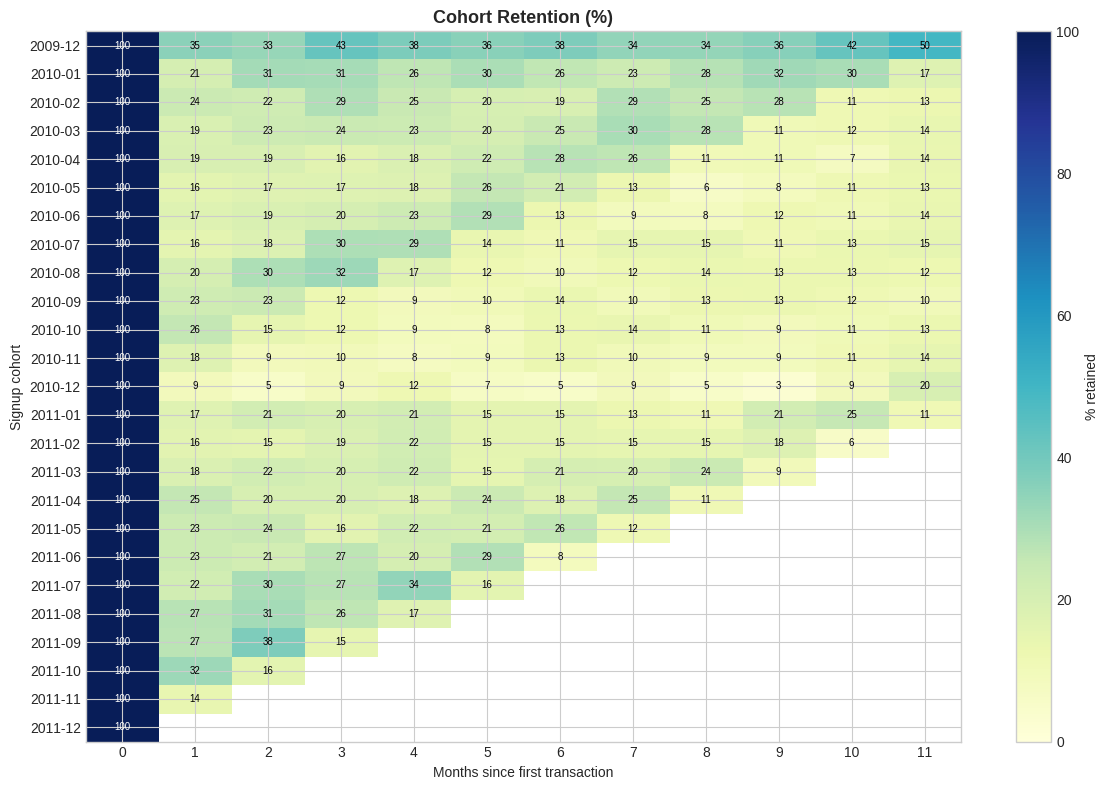

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
data = retention_pct.iloc[:, :12].values
im = ax.imshow(data, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(range(data.shape[1]))
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(retention_pct.index)
ax.set_xlabel("Months since first transaction")
ax.set_ylabel("Signup cohort")
ax.set_title("Cohort Retention (%)")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7, color="white" if val > 50 else "black")
plt.colorbar(im, label="% retained")
plt.tight_layout()
plt.show()

## 16. Does retention differ meaningfully across cohorts?

In [16]:
month3_retention = retention_pct[3].dropna()
overall_mean = month3_retention.mean()
overall_std = month3_retention.std()
print(f"Month-3 retention across {len(month3_retention)} cohorts: mean={overall_mean:.1f}%, std={overall_std:.1f}%")

mid = len(month3_retention) // 2
early, late = month3_retention.iloc[:mid], month3_retention.iloc[mid:]
t_stat, p_val = stats.ttest_ind(early, late, equal_var=False)
print(f"Early cohorts (n={len(early)}) mean: {early.mean():.1f}%  vs.  Late cohorts (n={len(late)}) mean: {late.mean():.1f}%")
print(f"t-test p-value: {p_val:.3f}  ({'statistically different' if p_val < 0.05 else 'not statistically different'} at p<0.05)")

Month-3 retention across 22 cohorts: mean=21.6%, std=8.3%
Early cohorts (n=11) mean: 24.3%  vs.  Late cohorts (n=11) mean: 19.0%
t-test p-value: 0.141  (not statistically different at p<0.05)


## 17. Revenue forecasting — with a naive baseline, residual diagnostics, and prediction intervals

In [17]:
monthly_full["month_idx"] = range(len(monthly_full))
monthly_full["month_num"] = pd.to_datetime(monthly_full["month"]).dt.month
monthly_enc = pd.get_dummies(monthly_full, columns=["month_num"], drop_first=True)
feature_cols = [c for c in monthly_enc.columns if c.startswith("month_num_")] + ["month_idx"]
X = monthly_enc[feature_cols].astype(float)
y = monthly_enc["revenue"]

X_train, X_test = X.iloc[:-FORECAST_TEST_MONTHS], X.iloc[-FORECAST_TEST_MONTHS:]
y_train, y_test = y.iloc[:-FORECAST_TEST_MONTHS], y.iloc[-FORECAST_TEST_MONTHS:]

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
mape = np.mean(np.abs((y_test.values - preds) / y_test.values)) * 100

# Naive baseline
naive_preds = np.full(FORECAST_TEST_MONTHS, y_train.iloc[-1])
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_mape = np.mean(np.abs((y_test.values - naive_preds) / y_test.values)) * 100

print(f"Model    — MAE: Rs {mae:,.0f}  MAPE: {mape:.1f}%")
print(f"Naive    — MAE: Rs {naive_mae:,.0f}  MAPE: {naive_mape:.1f}%")
print(f"Model improves on naive baseline by {(1 - mae/naive_mae)*100:.1f}%")

Model    — MAE: Rs 45,687  MAPE: 4.7%
Naive    — MAE: Rs 405,981  MAPE: 38.2%
Model improves on naive baseline by 88.7%


## 18. Residual diagnostics

In [18]:
train_preds = model.predict(X_train)
residuals = y_train.values - train_preds
lag1_autocorr = pd.Series(residuals).autocorr(lag=1)

print(f"Residual mean: Rs {residuals.mean():,.0f}  (should be ~0 for an unbiased fit)")
print(f"Residual std:  Rs {residuals.std():,.0f}")
print(f"Lag-1 autocorrelation: {lag1_autocorr:.3f}")
print("(Values well above ~0.3 in magnitude would suggest the model is missing structure —")
print(" e.g., a trend that isn't fully linear — and that significance claims from the regression")
print(" shouldn't be taken at face value.)")

Residual mean: Rs -0  (should be ~0 for an unbiased fit)
Residual std:  Rs 42,890
Lag-1 autocorrelation: 0.221
(Values well above ~0.3 in magnitude would suggest the model is missing structure —
 e.g., a trend that isn't fully linear — and that significance claims from the regression
 shouldn't be taken at face value.)


## 19. Visualization 6 — Residuals & actual vs. predicted with 95% prediction interval

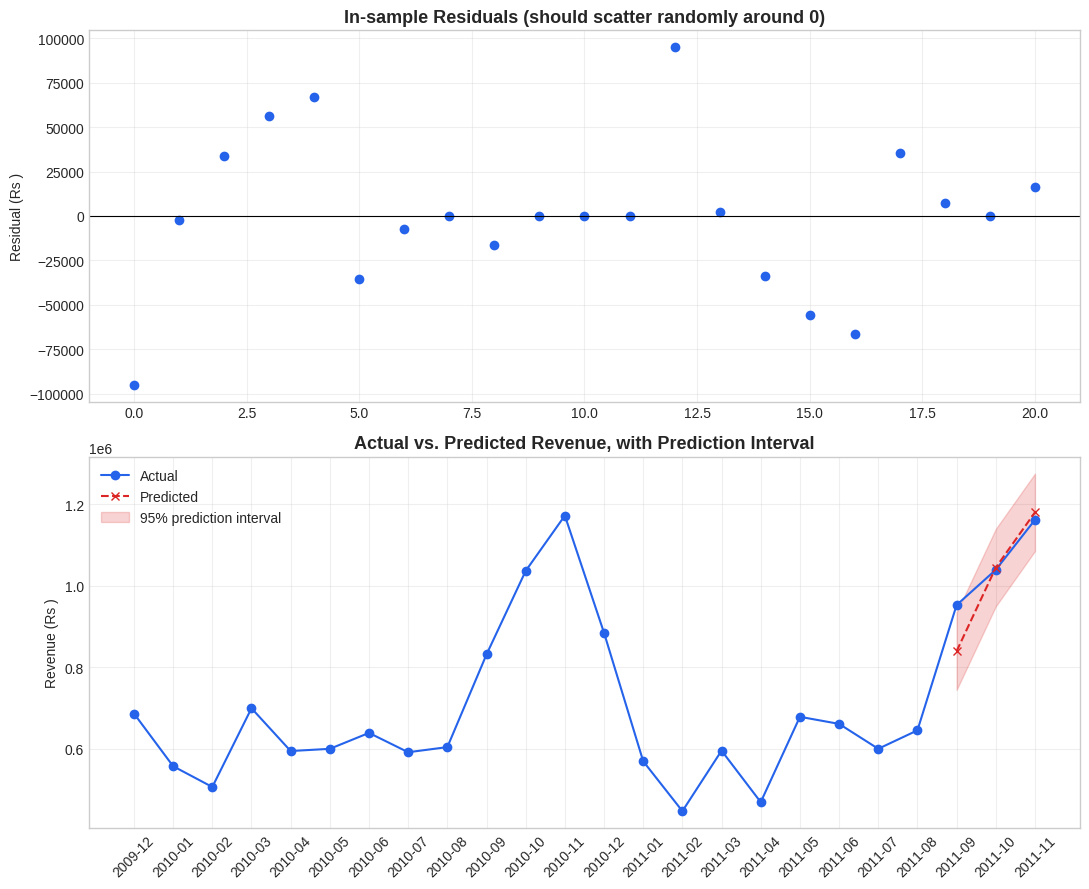

Actual values falling within the 95% prediction interval: 2 / 3
If this is below 3/3, the intervals are likely too narrow — they're built from in-sample
residual variance, which typically understates true out-of-sample forecast uncertainty.
Worth treating these intervals as a lower bound on uncertainty, not a guarantee.


<Figure size 1000x500 with 0 Axes>

Actual values falling within the 95% prediction interval: 2 / 3
If this is below 3/3, the intervals are likely too narrow -- they're built from in-sample
residual variance, which typically understates true out-of-sample forecast uncertainty.
Worth treating these intervals as a lower bound on uncertainty, not a guarantee.


In [19]:
rng = np.random.default_rng(SEED)
boot_samples = rng.choice(residuals, size=(N_BOOTSTRAP, FORECAST_TEST_MONTHS), replace=True)
pred_intervals = preds[None, :] + boot_samples
lower = np.percentile(pred_intervals, 2.5, axis=0)
upper = np.percentile(pred_intervals, 97.5, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(11, 9))

axes[0].scatter(range(len(residuals)), residuals, color=COLORS["primary"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("In-sample Residuals (should scatter randomly around 0)")
axes[0].set_ylabel("Residual (Rs )")
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_full["month"], monthly_full["revenue"], marker="o", label="Actual", color=COLORS["primary"])
test_months = monthly_full["month"].iloc[-FORECAST_TEST_MONTHS:].values
axes[1].plot(test_months, preds, marker="x", linestyle="--", label="Predicted", color=COLORS["warn"])
axes[1].fill_between(test_months, lower, upper, alpha=0.2, color=COLORS["warn"], label="95% prediction interval")
axes[1].set_title("Actual vs. Predicted Revenue, with Prediction Interval")
axes[1].set_ylabel("Revenue (Rs )")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

coverage = sum(l <= a <= u for l, a, u in zip(lower, y_test.values, upper))
print(f"Actual values falling within the 95% prediction interval: {coverage} / {FORECAST_TEST_MONTHS}")
print("If this is below 3/3, the intervals are likely too narrow — they're built from in-sample")
print("residual variance, which typically understates true out-of-sample forecast uncertainty.")
print("Worth treating these intervals as a lower bound on uncertainty, not a guarantee.")

plt.tight_layout()
plt.show()

coverage = sum(l <= a <= u for l, a, u in zip(lower, y_test.values, upper))
print(f"Actual values falling within the 95% prediction interval: {coverage} / {FORECAST_TEST_MONTHS}")
print("If this is below 3/3, the intervals are likely too narrow -- they're built from in-sample")
print("residual variance, which typically understates true out-of-sample forecast uncertainty.")
print("Worth treating these intervals as a lower bound on uncertainty, not a guarantee.")

## 20. Save results

In [20]:
rfm.to_csv("rfm_segments.csv", index=False)
monthly_full.to_csv("monthly_revenue.csv", index=False)
retention_pct.to_csv("cohort_retention.csv")
sensitivity.to_csv("churn_threshold_sensitivity.csv", index=False)
pd.DataFrame({"month": test_months, "actual": y_test.values, "predicted": preds, "lower_95": lower, "upper_95": upper}).to_csv("forecast_vs_actual.csv", index=False)
print("Saved all result CSVs.")

Saved all result CSVs.
